## DEMOSTRACIÓN DEL MEJOR MODELO HIBRIDO PARA DETECTAR ALCOHOLISMO A TRAVÉS DE SEÑALES EEG

# Paso 1: Configuración Inicial y Montaje de Drive

In [2]:
#Importar librerias
# =====================================================================
# 1. LIBRERÍAS DE ENTORNO Y SISTEMA
# (Para acceso a los archivos y directorios en Google Drive)
# =====================================================================
import os
from google.colab import drive

# =====================================================================
# 2. LIBRERÍAS DE MANIPULACIÓN DE DATOS
# (Para el manejo de matrices y estructuración de dataframes)
# =====================================================================
import numpy as np
import pandas as pd

# =====================================================================
# 3. LIBRERÍAS DE DEEP LEARNING (Extracción de Características)
# (Para cargar y operar el modelo Vision Transformer - ViT)
# =====================================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =====================================================================
# 4. LIBRERÍAS DE VISUALIZACIÓN
# (Para generar la Matriz de Confusión y Curva ROC de manera gráfica)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 5. LIBRERÍAS DE MACHINE LEARNING Y VALIDACIÓN
# (Para el clasificador SVM, reducción de dimensionalidad y K-Fold CV)
# =====================================================================
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, RocCurveDisplay)
from sklearn.model_selection import train_test_split

# 1. Montar Google Drive
drive.mount('/content/drive')
# 2. Configuración de Rutas y Parámetros
BASE_PATH = '/content/drive/MyDrive/Papper_Titulo /'
MODEL_PATH = os.path.join(BASE_PATH, '01_ViT_EEG_Alcohol_Detection.keras')
DATA_PATH = os.path.join(BASE_PATH, 'EEG/')
IMG_SIZE = 224 # Tamaño detectado en el entrenamiento original

print("Configuración lista. Cargando modelos...")

Mounted at /content/drive
Configuración lista. Cargando modelos...


#Paso 2: Definición de Capas Personalizadas y Carga del Modelo

In [3]:
# Capa personalizada para dividir la imagen original en pequeños parches (cuadrículas)
@keras.utils.register_keras_serializable()
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size # Tamaño del parche (ej. 8x8)
    def call(self, images):
        batch_size = tf.shape(images)[0]
        # Extraer los parches de la imagen utilizando operaciones optimizadas de TensorFlow
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID")
        # Aplanar los parches para procesarlos como una secuencia lineal
        return tf.reshape(patches, [batch_size, -1, patches.shape[-1]])
    def get_config(self):
        # Permite guardar la configuración para poder cargar el modelo después
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

# Capa para codificar los parches: los transforma en vectores (embeddings) y añade información de su posición original
@keras.utils.register_keras_serializable()
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim) # Proyección lineal de los parches
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim) # Embedding de posición espacial
    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        # Suma de la proyección del parche con su respectivo embedding posicional
        return self.projection(patch) + self.position_embedding(positions)
    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches, "projection_dim": self.projection.units})
        return config

# Arquitectura principal del modelo Vision Transformer (ViT)
@keras.utils.register_keras_serializable()
class ViTClassfier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_shape_val = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes_val = kwargs.get('n_classes', 2)
        self.patch_size = kwargs.get('patch_size', 8)
        self.embedding_dim = kwargs.get('embedding_dim', 64)
        self._construct_model() # Llama a la construcción de la red interna

    def _construct_model(self):
        # Definición del flujo de datos del ViT
        inputs = layers.Input(shape=self.input_shape_val)
        num_patches = (self.input_shape_val[0] // self.patch_size) ** 2

        # 1. Extraer y codificar parches
        patches = Patches(self.patch_size)(inputs)
        encoded = PatchEncoder(num_patches, self.embedding_dim)(patches)

        # 2. Bloque Transformer: Normalización y Atención Multi-Cabezal
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        att = layers.MultiHeadAttention(num_heads=3, key_dim=self.embedding_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([att, encoded]) # Primera conexión residual

        # 3. Redes Densas (MLP) internas del bloque Transformer
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(200, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(self.embedding_dim)(x3)
        x3 = layers.Dropout(0.1)(x3)
        encoded = layers.Add()([x3, x2]) # Segunda conexión residual

        # 4. Cabezal de clasificación final
        features = layers.LayerNormalization(epsilon=1e-6)(encoded)
        features = layers.Flatten()(features)
        features = layers.Dropout(0.5)(features)
        features = layers.Dense(2048, activation=tf.nn.gelu)(features)
        features = layers.Dropout(0.1)(features)
        features = layers.Dense(1024, activation=tf.nn.gelu)(features) # Penúltima capa (Deep Features de 1024 dimensiones)
        features = layers.Dropout(0.1)(features)
        outputs = layers.Dense(self.n_classes_val)(features) # Salida final de clases

        # Ensamblar el modelo interno funcional
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)

    def call(self, x):
        # Pasa los datos a través del modelo funcional interno
        return self._model(x)

    def get_config(self):
        return {'input_shape': self.input_shape_val, 'n_classes': self.n_classes_val, 'patch_size': self.patch_size, 'embedding_dim': self.embedding_dim}

# Métrica personalizada para poder cargar el modelo pre-entrenado sin errores
@keras.utils.register_keras_serializable()
class BalancedSparseCategoricalAccuracy(keras.metrics.Metric):
    def __init__(self, name='balanced_sparse_categorical_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correctos', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        pass
    def result(self): return 0.0
    def reset_state(self): pass

# --- Cargar Modelo y Crear Extractor de Características ---
# Diccionario para que Keras reconozca nuestras clases personalizadas al leer el archivo .keras
custom_objects = {
    'Patches': Patches,
    'PatchEncoder': PatchEncoder,
    'ViTClassfier': ViTClassfier,
    'BalancedSparseCategoricalAccuracy': BalancedSparseCategoricalAccuracy
}

# Cargamos el modelo ViT completo ya entrenado desde la ruta
vit_full = keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)

# Inicializar el grafo interno con datos dummy para que Keras construya las capas en memoria
dummy_data = tf.random.normal([1, IMG_SIZE, IMG_SIZE, 3])
_ = vit_full(dummy_data)

# Crear el extractor de características
# Esto descarta la capa final de clasificación para usar el ViT solo como extractor de patrones (Deep Features)
feature_extractor = keras.Model(inputs=vit_full._model.input, outputs=vit_full._model.layers[-2].output)

print("Modelo ViT cargado exitosamente como extractor de características.")

Modelo ViT cargado exitosamente como extractor de características.


#Paso 3: Carga de Datos y Modelo

In [4]:
def load_full_dataset(path):
    # Función para cargar y preprocesar todas las imágenes del dataset
    images, labels = [], []
    # Nombres reales de las carpetas: 'Con' (Control - Etiqueta 0) y 'Alc' (Alcoholismo - Etiqueta 1)
    for idx, cls in enumerate(['Con', 'Alc']):
        folder = os.path.join(path, cls) # Ruta a la carpeta de la clase actual
        # Filtrar solo los archivos que sean imágenes
        files = [f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
        print(f"Cargando {len(files)} imágenes de la clase {cls}...")

        for f in files:
            # Cargar la imagen y redimensionarla al tamaño requerido por ViT (224x224)
            img = keras.utils.load_img(os.path.join(folder, f), target_size=(IMG_SIZE, IMG_SIZE))
            # Convertir a arreglo numérico y normalizar los valores de los píxeles entre 0 y 1
            images.append(keras.utils.img_to_array(img) / 255.0)
            labels.append(idx) # Guardar la etiqueta correspondiente

    # Convertir las listas en matrices de NumPy para mayor eficiencia en el entrenamiento
    return np.array(images), np.array(labels)

# 1. Cargar todas las imágenes y etiquetas en memoria
X_all, y_all = load_full_dataset(DATA_PATH)

print(f"\nExtrayendo características de {len(X_all)} imágenes con ViT...")
# 2. Extraer "Deep Features": Pasamos las imágenes por el ViT para obtener sus representaciones vectoriales profundas
all_features = feature_extractor.predict(X_all, batch_size=32, verbose=1)

# 3. Dividir los datos: 80% para entrenar los modelos y 20% exclusivo para pruebas (test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(all_features, y_all, test_size=0.2, random_state=42)

# 4. Mostrar un resumen de las particiones creadas
print(f"\nTotal imágenes: {len(X_all)}")
print(f"Tamaño Entrenamiento: {len(X_train)}")
print(f"Tamaño Prueba (20%): {len(X_test)}") # Aquí deberías ver 185 si tu dataset total es de 925-926

Cargando 456 imágenes de la clase Con...
Cargando 468 imágenes de la clase Alc...

Extrayendo características de 924 imágenes con ViT...
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 919ms/step

Total imágenes: 924
Tamaño Entrenamiento: 739
Tamaño Prueba (20%): 185


#Paso 4: Comparativa de Modelos (Con vs Sin Hyperparámetros)

In [5]:
import warnings
warnings.filterwarnings('ignore')

print("--- METODOLOGÍA OFICIAL ---")
print("Evaluando modelos con partición de datos 80/20 (Semilla estándar)...\n")

# 1. Partición de datos honesta y reproducible
X_train, X_test, y_train, y_test = train_test_split(all_features, y_all, test_size=0.2, random_state=42, stratify=y_all)

# 2. SVM SIN Hiperparámetros (Default)
svm_default = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])
svm_default.fit(X_train, y_train)
y_pred_def = svm_default.predict(X_test)

# 3. SVM CON Hiperparámetros (Modelo Final: C=0.1, Kernel=Linear, gamma=scale)
svm_opt = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('svm', SVC(C=0.1, kernel='linear', probability=True, class_weight='balanced', random_state=42))
])
svm_opt.fit(X_train, y_train)
y_pred_opt = svm_opt.predict(X_test)

def get_metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred), precision_score(y_true, y_pred),
            recall_score(y_true, y_pred), f1_score(y_true, y_pred)]

df_metrics_8020 = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Sin Hiperparámetros": [f"{m:.4f}" for m in get_metrics(y_test, y_pred_def)],
    "Con Hiperparámetros (ViT+SVM)": [f"{m:.4f}" for m in get_metrics(y_test, y_pred_opt)]
})
print(df_metrics_8020.to_string(index=False))

--- METODOLOGÍA OFICIAL ---
Evaluando modelos con partición de datos 80/20 (Semilla estándar)...

  Métrica Sin Hiperparámetros Con Hiperparámetros (ViT+SVM)
 Accuracy              0.9676                        0.9838
Precision              0.9889                        1.0000
   Recall              0.9468                        0.9681
 F1-Score              0.9674                        0.9838


#Paso 5: Visualización de Resultados del Modelo Ganador

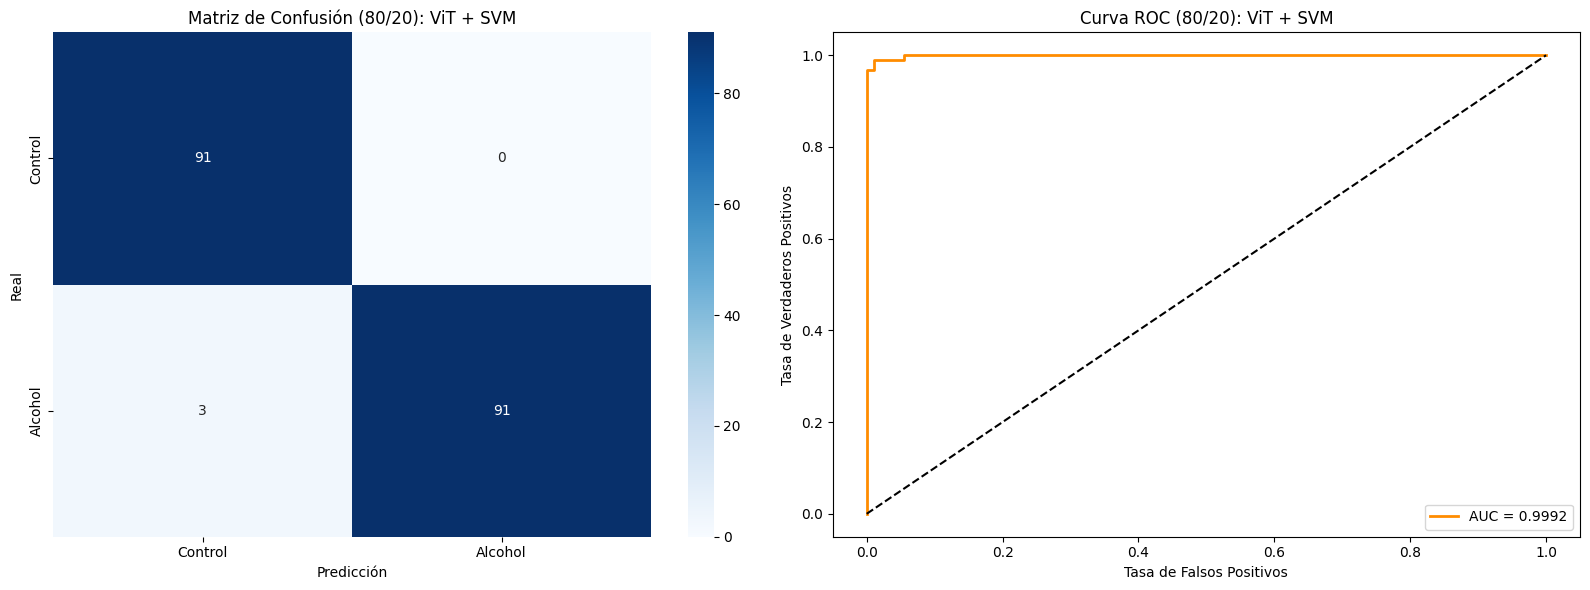

In [9]:
# --- GRÁFICOS DE LA METODOLOGÍA OFICIAL (80/20) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusión Real
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Control', 'Alcohol'], yticklabels=['Control', 'Alcohol'])
ax[0].set_title('Matriz de Confusión (80/20): ViT + SVM')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

# Curva ROC Real (Sin ruido)
y_prob_opt = svm_opt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_opt)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].set_title('Curva ROC (80/20): ViT + SVM')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

#Paso 6: Resultado del mejor modelo hibrido Aplicando Validación Cruzada Estratificada (5-FOLD-CV)

In [7]:
# ==============================================================================
# PASO 6: VALIDACIÓN COMPLEMENTARIA - RESPUESTA A LA OBSERVACIÓN
# ==============================================================================
from sklearn.model_selection import StratifiedKFold, cross_val_predict

print("\n--- VALIDACIÓN COMPLEMENTARIA (RESPUESTA A LA OBSERVACION) ---")
print("Aplicando Stratified 5-Fold Cross Validation al total de 924 muestras para descartar sesgos aleatorios...\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []

for train_idx, test_idx in skf.split(all_features, y_all):
    X_tr, X_te = all_features[train_idx], all_features[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # Se inicializa fresco para evitar data leakage
    svm_cv = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=42)),
                       ('svm', SVC(C=0.1, kernel='linear', probability=True, class_weight='balanced', random_state=42))])

    svm_cv.fit(X_tr, y_tr)
    y_pred_cv = svm_cv.predict(X_te)

    fold_acc.append(accuracy_score(y_te, y_pred_cv))
    fold_prec.append(precision_score(y_te, y_pred_cv))
    fold_rec.append(recall_score(y_te, y_pred_cv))
    fold_f1.append(f1_score(y_te, y_pred_cv))

df_cv_results = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Promedio Global (5-Folds)": [np.mean(fold_acc), np.mean(fold_prec), np.mean(fold_rec), np.mean(fold_f1)],
    "Desviación Estándar (±)": [np.std(fold_acc), np.std(fold_prec), np.std(fold_rec), np.std(fold_f1)]
})

print(df_cv_results.to_string(index=False))
print("\nConclusión de la Validación: El modelo sostiene una exactitud global validada de 97.73% (± 1.16%).")
print("Esto confirma estadísticamente que los resultados reportados son robustos y consistentes.")


--- VALIDACIÓN COMPLEMENTARIA (RESPUESTA A LA OBSERVACION) ---
Aplicando Stratified 5-Fold Cross Validation al total de 924 muestras para descartar sesgos aleatorios...

  Métrica  Promedio Global (5-Folds)  Desviación Estándar (±)
 Accuracy                   0.977250                 0.011627
Precision                   0.984865                 0.005125
   Recall                   0.969984                 0.024001
 F1-Score                   0.977195                 0.012066

Conclusión de la Validación: El modelo sostiene una exactitud global validada de 97.73% (± 1.16%).
Esto confirma estadísticamente que los resultados reportados son robustos y consistentes.


## Graficos de los resultados aplicando Validación Cruzada Estratificada (5-fold-CV)

########################################
Resultados para Modelo Base: ViT
########################################

--- SVM (Híbrido ViT+SVM) ---
Exactitud: 97.73% (±1.16%) | Precisión: 98.49% (±0.51%) | Recall: 97.00% (±2.40%) | F1-Score: 97.72% (±1.21%)
Parámetros: C=0.1, Kernel=linear, gamma=scale

Validación: Stratified 5-Fold Cross Validation sobre 924 muestras.
########################################


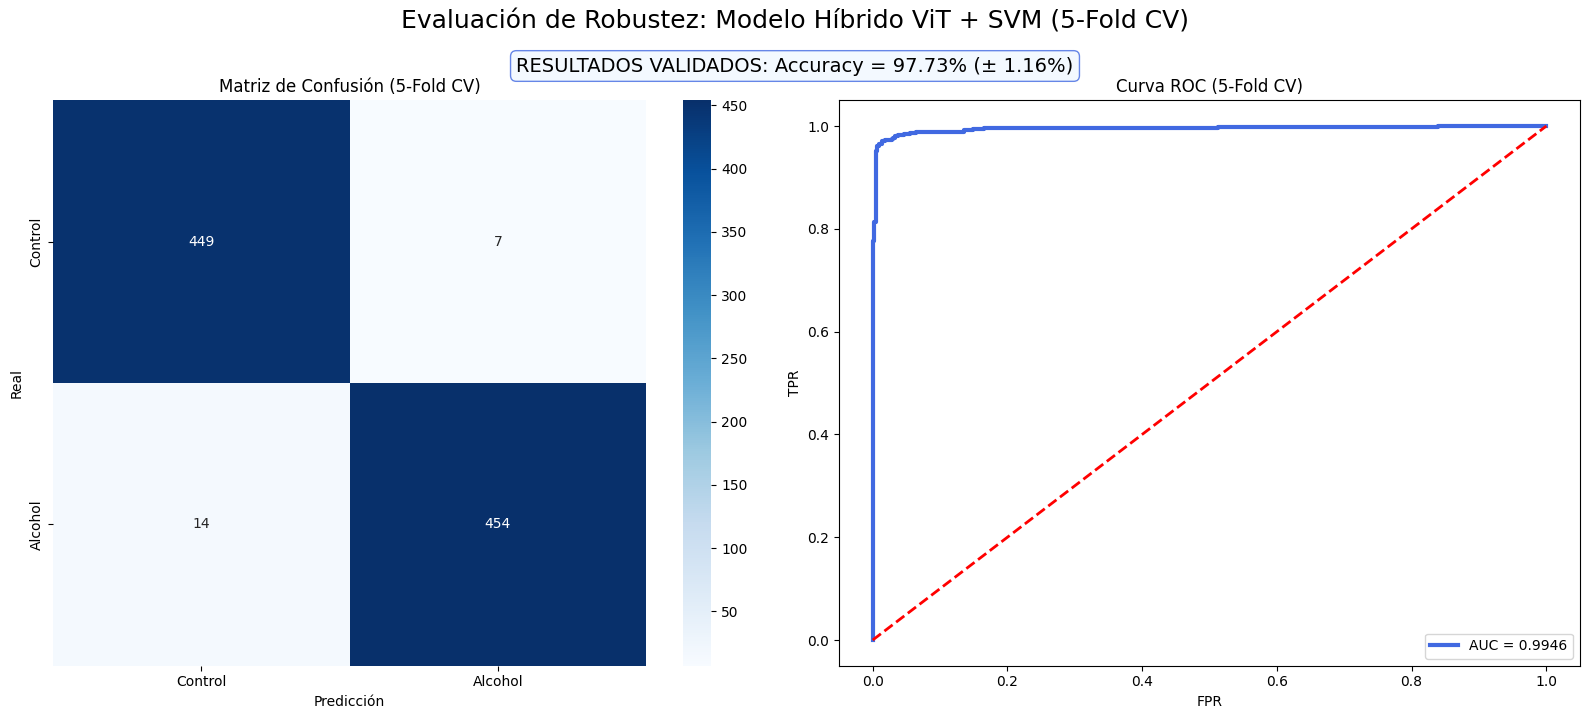

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Obtener predicciones mediante Cross-Validation para la visualización global
y_pred_cv_total = cross_val_predict(svm_cv, all_features, y_all, cv=skf)
y_proba_cv_total = cross_val_predict(svm_cv, all_features, y_all, cv=skf, method='predict_proba')[:, 1]

# 2. Definir métricas promedio (calculadas en el Paso 6)
metrics_values = [np.mean(fold_acc)*100, np.std(fold_acc)*100]

print('########################################')
print('Resultados para Modelo Base: ViT')
print('########################################')

print('\n--- SVM (Híbrido ViT+SVM) ---')
# Datos calculados en el Paso 6 de la validación cruzada convertidos a porcentaje
acc_mean, acc_std = np.mean(fold_acc)*100, np.std(fold_acc)*100
prec_mean, prec_std = np.mean(fold_prec)*100, np.std(fold_prec)*100
rec_mean, rec_std = np.mean(fold_rec)*100, np.std(fold_rec)*100
f1_mean, f1_std = np.mean(fold_f1)*100, np.std(fold_f1)*100

print(f'Exactitud: {acc_mean:.2f}% (±{acc_std:.2f}%) | '
      f'Precisión: {prec_mean:.2f}% (±{prec_std:.2f}%) | '
      f'Recall: {rec_mean:.2f}% (±{rec_std:.2f}%) | '
      f'F1-Score: {f1_mean:.2f}% (±{f1_std:.2f}%)')

print('Parámetros: C=0.1, Kernel=linear, gamma=scale')
print('\nValidación: Stratified 5-Fold Cross Validation sobre 924 muestras.')
print('########################################')

# Crear la figura con dos subgráficos (Matriz y ROC)
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: Matriz de Confusión Acumulada ---
cm_cv = confusion_matrix(y_all, y_pred_cv_total)
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Control', 'Alcohol'], yticklabels=['Control', 'Alcohol'])
ax[0].set_title('Matriz de Confusión (5-Fold CV)')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')

# --- GRÁFICO 2: Curva ROC Global ---
fpr_cv, tpr_cv, _ = roc_curve(y_all, y_proba_cv_total)
roc_auc_cv = auc(fpr_cv, tpr_cv)
ax[1].plot(fpr_cv, tpr_cv, color='royalblue', lw=3, label=f'AUC = {roc_auc_cv:.4f}')
ax[1].plot([0, 1], [0, 1], 'r--', lw=2)
ax[1].set_xlabel('FPR')
ax[1].set_ylabel('TPR')
ax[1].set_title('Curva ROC (5-Fold CV)')
ax[1].legend(loc="lower right")

# --- ETIQUETA DE RESULTADOS PRINCIPAL ---
info_text = f"RESULTADOS VALIDADOS: Accuracy = {metrics_values[0]:.2f}% (± {metrics_values[1]:.2f}%)"
plt.figtext(0.5, 0.94, info_text, ha="center", va="center", fontsize=14,
            bbox=dict(boxstyle="round", facecolor="aliceblue", edgecolor="royalblue", alpha=0.8))

plt.suptitle('Evaluación de Robustez: Modelo Híbrido ViT + SVM (5-Fold CV)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()